In [1]:
"""
================================================================================
Name:Karthik Moorthy
Date:25/1/2026
BREAST CANCER CLASSIFICATION - ML ASSIGNMENT 2 BITS Pilani M.Tech (AIML)

Dataset: Breast Cancer Wisconsin (Diagnostic)
Models: 6 Classification Algorithms
Metrics: Accuracy, AUC, Precision, Recall, F1, MCC
================================================================================
"""
print("="*80)
print("🎓 BITS Pilani - Machine Learning Assignment 2")
print("📊 Breast Cancer Classification Model Training")
print("="*80)

🎓 BITS Pilani - Machine Learning Assignment 2
📊 Breast Cancer Classification Model Training


In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, confusion_matrix, 
    classification_report, roc_curve
)

# XGBoost
from xgboost import XGBClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import pickle
import os
import warnings
from datetime import datetime
import json

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f"📅 Execution Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully!
📅 Execution Date: 2026-01-27 03:31:52


In [3]:
# ==========================================
# CONFIGURATION - UPDATE THESE PATHS
# ==========================================

# Dataset path
DATASET_PATH = 'data.csv'  # Update this to your dataset path

# Target column name
TARGET_COLUMN = 'diagnosis'  # Column with M/B labels

# Output directories
MODEL_DIR = 'models'
RESULTS_DIR = 'results'

# Create directories if they don't exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# Random seed for reproducibility
RANDOM_STATE = 42

# Test size
TEST_SIZE = 0.2

print(" Configuration:")
print(f"   Dataset: {DATASET_PATH}")
print(f"   Target Column: {TARGET_COLUMN}")
print(f"   Model Directory: {MODEL_DIR}")
print(f"   Results Directory: {RESULTS_DIR}")
print(f"   Random State: {RANDOM_STATE}")
print(f"   Test Size: {TEST_SIZE}")

 Configuration:
   Dataset: data.csv
   Target Column: diagnosis
   Model Directory: models
   Results Directory: results
   Random State: 42
   Test Size: 0.2


In [4]:
# ==========================================
# CONFIGURATION
# ==========================================

# Dataset path - UPDATE THIS if needed
DATASET_PATH = 'data.csv'

# Target column name
TARGET_COLUMN = 'diagnosis'

# Output directories
MODEL_DIR = 'models'
RESULTS_DIR = 'results'

# Settings
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Create directories
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("="*80)
print("⚙️ CONFIGURATION")
print("="*80)
print(f"📁 Current Directory: {os.getcwd()}")
print(f"📄 Dataset Path: {DATASET_PATH}")
print(f"🎯 Target Column: {TARGET_COLUMN}")
print(f"📁 Model Directory: {MODEL_DIR}/")
print(f"📁 Results Directory: {RESULTS_DIR}/")
print(f"🎲 Random State: {RANDOM_STATE}")
print(f"📊 Test Size: {TEST_SIZE}")
print("="*80)

⚙️ CONFIGURATION
📁 Current Directory: C:\Users\mok8kor\Desktop\BITS_Assignment
📄 Dataset Path: data.csv
🎯 Target Column: diagnosis
📁 Model Directory: models/
📁 Results Directory: results/
🎲 Random State: 42
📊 Test Size: 0.2


In [5]:
# ==========================================
# LOAD DATASET
# ==========================================

print("\n" + "="*80)
print("📂 LOADING DATASET")
print("="*80)

df = None

# Method 1: Try to load from file
if os.path.exists(DATASET_PATH):
    try:
        df = pd.read_csv(DATASET_PATH)
        print(f"✅ Loaded from file: {DATASET_PATH}")
    except Exception as e:
        print(f"⚠️ Error reading file: {e}")

# Method 2: Search for CSV files
if df is None:
    print(f"⚠️ '{DATASET_PATH}' not found")
    print(f"🔍 Searching for CSV files...")
    
    csv_files = [f for f in os.listdir() if f.endswith('.csv')]
    
    if csv_files:
        print(f"📄 Found {len(csv_files)} CSV file(s):")
        for i, file in enumerate(csv_files, 1):
            print(f"   {i}. {file}")
        
        if len(csv_files) == 1:
            DATASET_PATH = csv_files[0]
            df = pd.read_csv(DATASET_PATH)
            print(f"✅ Auto-loaded: {DATASET_PATH}")

# Method 3: Use sklearn sample data
if df is None:
    print("\n📦 Loading sample Breast Cancer dataset from sklearn...")
    from sklearn.datasets import load_breast_cancer
    
    data = load_breast_cancer()
    df = pd.DataFrame(data.data, columns=data.feature_names)
    df['diagnosis'] = data.target_names[data.target]
    df.insert(0, 'id', range(1, len(df) + 1))
    
    DATASET_PATH = 'data.csv'
    df.to_csv(DATASET_PATH, index=False)
    print(f"✅ Sample dataset loaded and saved to: {DATASET_PATH}")

# Display info
print(f"\n📊 Dataset Information:")
print(f"   Shape: {df.shape}")
print(f"   Rows: {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")
print(f"   Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n📋 First 5 rows:")
display(df.head())

print("\n✅ Dataset loaded successfully!")


📂 LOADING DATASET
✅ Loaded from file: data.csv

📊 Dataset Information:
   Shape: (569, 31)
   Rows: 569
   Columns: 31
   Memory: 0.17 MB

📋 First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant



✅ Dataset loaded successfully!


In [6]:
# ==========================================
# EXPLORATORY DATA ANALYSIS
# ==========================================

print("\n" + "="*80)
print("🔍 EXPLORATORY DATA ANALYSIS")
print("="*80)

# Basic info
print(f"\n1️⃣ Dataset Information:")
print(f"   Total Samples: {len(df)}")
print(f"   Total Features: {len(df.columns)}")

# Column info
print(f"\n2️⃣ Columns ({len(df.columns)}):")
print(f"   {df.columns.tolist()[:10]}..." if len(df.columns) > 10 else f"   {df.columns.tolist()}")

# Data types
print(f"\n3️⃣ Data Types:")
print(df.dtypes.value_counts())

# Missing values
print(f"\n4️⃣ Missing Values:")
missing = df.isnull().sum().sum()
if missing == 0:
    print("   ✅ No missing values!")
else:
    print(f"   ⚠️ {missing} missing values found")

# Target distribution
if TARGET_COLUMN in df.columns:
    print(f"\n5️⃣ Target Distribution ('{TARGET_COLUMN}'):")
    print(df[TARGET_COLUMN].value_counts())
    print(f"\n   Percentages:")
    print((df[TARGET_COLUMN].value_counts(normalize=True) * 100).round(2))

# Summary statistics
print(f"\n6️⃣ Summary Statistics:")
display(df.describe())


🔍 EXPLORATORY DATA ANALYSIS

1️⃣ Dataset Information:
   Total Samples: 569
   Total Features: 31

2️⃣ Columns (31):
   ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']...

3️⃣ Data Types:
float64    30
object      1
Name: count, dtype: int64

4️⃣ Missing Values:
   ✅ No missing values!

5️⃣ Target Distribution ('diagnosis'):
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

   Percentages:
diagnosis
benign       62.74
malignant    37.26
Name: proportion, dtype: float64

6️⃣ Summary Statistics:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [7]:
# ==========================================
# DATA PREPROCESSING
# ==========================================

print("\n" + "="*80)
print("🔧 DATA PREPROCESSING")
print("="*80)

# Drop unnecessary columns
columns_to_drop = ['id', 'Unnamed: 32']
df_clean = df.drop(columns=columns_to_drop, errors='ignore')
dropped = [col for col in columns_to_drop if col in df.columns]

if dropped:
    print(f"✅ Dropped columns: {dropped}")
else:
    print(f"ℹ️ No unnecessary columns to drop")

print(f"   Shape after cleaning: {df_clean.shape}")

# Verify target column exists
if TARGET_COLUMN not in df_clean.columns:
    raise ValueError(f"❌ Target column '{TARGET_COLUMN}' not found in dataset!")

# Separate features and target
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

print(f"\n📊 Data Split:")
print(f"   Features (X): {X.shape}")
print(f"   Target (y): {y.shape}")

# Display target info
print(f"\n🎯 Target Variable ('{TARGET_COLUMN}'):")
print(f"   Unique values: {y.unique()}")
print(f"   Value counts:")
for val, count in y.value_counts().items():
    print(f"      '{val}': {count} ({count/len(y)*100:.1f}%)")

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\n🔄 Label Encoding:")
print(f"   Classes: {label_encoder.classes_}")
for i, cls in enumerate(label_encoder.classes_):
    count = sum(y_encoded == i)
    print(f"   '{cls}' → {i} ({count} samples, {count/len(y_encoded)*100:.1f}%)")

# Feature information
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f"\n📋 Feature Types:")
print(f"   Numerical: {len(numerical_cols)}")
print(f"   Categorical: {len(categorical_cols)}")

if len(X.columns) <= 10:
    print(f"   Feature names: {X.columns.tolist()}")
else:
    print(f"   Sample features: {X.columns.tolist()[:5]}... (showing first 5)")

print("\n✅ Preprocessing complete!")


🔧 DATA PREPROCESSING
ℹ️ No unnecessary columns to drop
   Shape after cleaning: (569, 31)

📊 Data Split:
   Features (X): (569, 30)
   Target (y): (569,)

🎯 Target Variable ('diagnosis'):
   Unique values: ['malignant' 'benign']
   Value counts:
      'benign': 357 (62.7%)
      'malignant': 212 (37.3%)

🔄 Label Encoding:
   Classes: ['benign' 'malignant']
   'benign' → 0 (357 samples, 62.7%)
   'malignant' → 1 (212 samples, 37.3%)

📋 Feature Types:
   Numerical: 30
   Categorical: 0
   Sample features: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']... (showing first 5)

✅ Preprocessing complete!


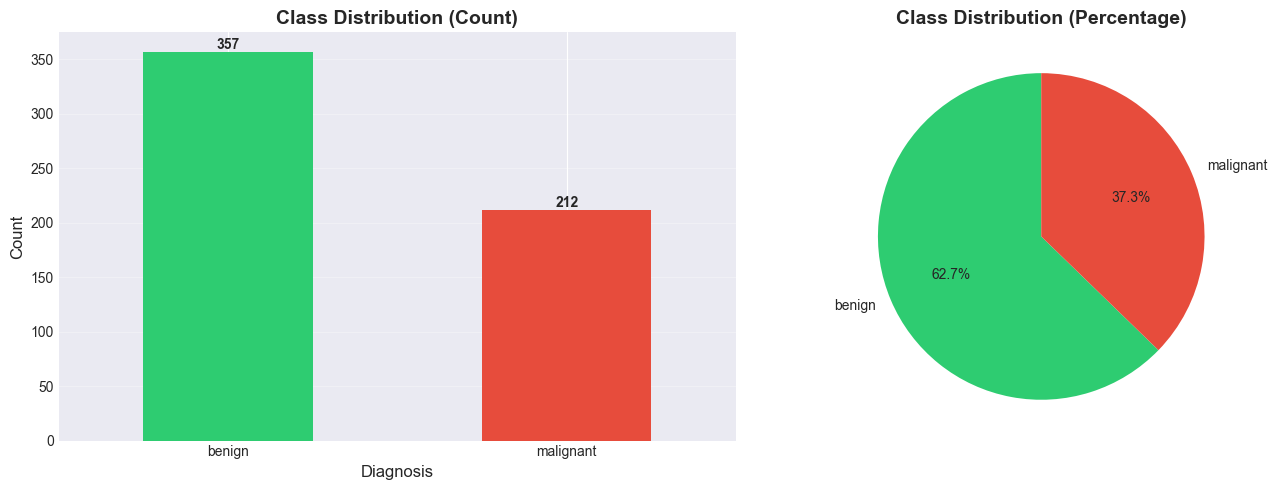

✅ Class distribution plot saved!


In [8]:
# ==========================================
# VISUALIZE CLASS DISTRIBUTION
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
y.value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(axis='y', alpha=0.3)

for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=10, fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
y.value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                      colors=colors, startangle=90)
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Class distribution plot saved!")

In [9]:
# ==========================================
# TRAIN-TEST SPLIT
# ==========================================

print("\n" + "="*80)
print("✂️ TRAIN-TEST SPLIT")
print("="*80)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y_encoded, 
    test_size=TEST_SIZE, 
    random_state=RANDOM_STATE, 
    stratify=y_encoded
)

print(f"✅ Data split completed!")

print(f"\n📊 Training Set:")
print(f"   Samples: {len(X_train):,}")
print(f"   Features: {X_train.shape[1]}")
print(f"   Class distribution:")
for i, cls in enumerate(label_encoder.classes_):
    count = sum(y_train == i)
    print(f"      {cls} ({i}): {count} ({count/len(y_train)*100:.1f}%)")

print(f"\n📊 Test Set:")
print(f"   Samples: {len(X_test):,}")
print(f"   Features: {X_test.shape[1]}")
print(f"   Class distribution:")
for i, cls in enumerate(label_encoder.classes_):
    count = sum(y_test == i)
    print(f"      {cls} ({i}): {count} ({count/len(y_test)*100:.1f}%)")

print(f"\n📈 Split Ratio:")
print(f"   Training: {len(X_train)/len(X)*100:.1f}%")
print(f"   Testing: {len(X_test)/len(X)*100:.1f}%")

print(f"\n✅ Total: {len(X)} = {len(X_train)} + {len(X_test)}")


✂️ TRAIN-TEST SPLIT
✅ Data split completed!

📊 Training Set:
   Samples: 455
   Features: 30
   Class distribution:
      benign (0): 285 (62.6%)
      malignant (1): 170 (37.4%)

📊 Test Set:
   Samples: 114
   Features: 30
   Class distribution:
      benign (0): 72 (63.2%)
      malignant (1): 42 (36.8%)

📈 Split Ratio:
   Training: 80.0%
   Testing: 20.0%

✅ Total: 569 = 455 + 114


In [10]:
# ==========================================
# FEATURE SCALING
# ==========================================

print("\n" + "="*80)
print("⚖️ FEATURE SCALING")
print("="*80)

# Initialize and fit scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Features scaled using StandardScaler")

print(f"\n📊 Training Data (Scaled):")
print(f"   Shape: {X_train_scaled.shape}")
print(f"   Mean: {X_train_scaled.mean():.10f} (≈ 0)")
print(f"   Std: {X_train_scaled.std():.10f} (≈ 1)")
print(f"   Min: {X_train_scaled.min():.4f}")
print(f"   Max: {X_train_scaled.max():.4f}")

print(f"\n📊 Test Data (Scaled):")
print(f"   Shape: {X_test_scaled.shape}")
print(f"   Mean: {X_test_scaled.mean():.10f}")
print(f"   Std: {X_test_scaled.std():.10f}")

# Save scaler
scaler_path = os.path.join(MODEL_DIR, 'scaler.pkl')
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"\n💾 Scaler saved to: {scaler_path}")

# Show sample
print("\n📋 Sample Scaled Data (first 3 rows, first 5 features):")
scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
display(scaled_df.head(3).iloc[:, :5])

print("\n✅ Feature scaling complete!")


⚖️ FEATURE SCALING
✅ Features scaled using StandardScaler

📊 Training Data (Scaled):
   Shape: (455, 30)
   Mean: 0.0000000000 (≈ 0)
   Std: 1.0000000000 (≈ 1)
   Min: -2.7338
   Max: 11.4841

📊 Test Data (Scaled):
   Shape: (114, 30)
   Mean: -0.0240085134
   Std: 0.9311264898

💾 Scaler saved to: models\scaler.pkl

📋 Sample Scaled Data (first 3 rows, first 5 features):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,0.518559,0.891826,0.424632,0.383925,-0.974744
1,-0.516364,-1.639710,-0.541349,-0.542961,0.476219
2,-0.368118,0.455515,-0.388250,-0.402970,-1.432979



✅ Feature scaling complete!


In [11]:
# ==========================================
# DEFINE MACHINE LEARNING MODELS
# ==========================================

print("\n" + "="*80)
print("🤖 DEFINING MACHINE LEARNING MODELS")
print("="*80)

models = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        solver='liblinear'
    ),
    
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ),
    
    "K-Nearest Neighbor": KNeighborsClassifier(
        n_neighbors=5,
        weights='uniform',
        metric='euclidean'
    ),
    
    "Naive Bayes": GaussianNB(),
    
    "Random Forest": RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ),
    
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        enable_categorical=False,
        tree_method='hist'
    )
}

print(f"✅ {len(models)} models defined:\n")
for i, name in enumerate(models.keys(), 1):
    print(f"   {i}. {name}")

print("\n" + "="*80)


🤖 DEFINING MACHINE LEARNING MODELS
✅ 6 models defined:

   1. Logistic Regression
   2. Decision Tree
   3. K-Nearest Neighbor
   4. Naive Bayes
   5. Random Forest
   6. XGBoost



In [12]:
# ==========================================
# TRAINING AND EVALUATION FUNCTION
# ==========================================

def train_and_evaluate(model_name, model, X_train, y_train, X_test, y_test):
    """
    Train a model and calculate all evaluation metrics.
    
    Returns: dict with all metrics
    """
    print(f"\n{'='*80}")
    print(f"🔄 Training: {model_name}")
    print(f"{'='*80}")
    
    # Train model
    try:
        model.fit(X_train, y_train)
        print(f"✅ Training completed!")
    except Exception as e:
        print(f"❌ Training failed: {e}")
        return None
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    mcc = matthews_corrcoef(y_test, y_pred)
    
    # AUC Score
    try:
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, y_proba)
        elif hasattr(model, 'decision_function'):
            y_scores = model.decision_function(X_test)
            auc = roc_auc_score(y_test, y_scores)
        else:
            auc = 0.0
    except Exception as e:
        auc = 0.0
        print(f"⚠️ AUC calculation failed: {e}")
    
    # Display metrics
    print(f"\n📊 Performance Metrics:")
    print(f"   Accuracy:  {accuracy:.4f}")
    print(f"   AUC:       {auc:.4f}")
    print(f"   Precision: {precision:.4f}")
    print(f"   Recall:    {recall:.4f}")
    print(f"   F1 Score:  {f1:.4f}")
    print(f"   MCC:       {mcc:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n📋 Confusion Matrix:")
    print(f"   [[{cm[0,0]:3d}  {cm[0,1]:3d}]]")
    print(f"   [[{cm[1,0]:3d}  {cm[1,1]:3d}]]")
    print(f"   TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}")
    
    # Classification Report
    print(f"\n📄 Classification Report:")
    print(classification_report(y_test, y_pred, 
                                target_names=label_encoder.classes_,
                                zero_division=0))
    
    # Save model
    model_filename = f"{model_name.lower().replace(' ', '_')}_model.pkl"
    model_path = os.path.join(MODEL_DIR, model_filename)
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"💾 Model saved: {model_path}")
    
    return {
        'ML Model Name': model_name,
        'Accuracy': round(accuracy, 4),
        'AUC': round(auc, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1': round(f1, 4),
        'MCC': round(mcc, 4),
        'Confusion Matrix': cm,
        'Predictions': y_pred
    }

print("✅ Training function defined successfully!")

✅ Training function defined successfully!


In [13]:
# ==========================================
# TRAIN ALL MODELS
# ==========================================

print("\n" + "="*80)
print("🚀 TRAINING ALL MODELS")
print("="*80)

all_results = []

for i, (model_name, model) in enumerate(models.items(), 1):
    print(f"\n[{i}/{len(models)}] Processing: {model_name}")
    print("─" * 80)
    
    result = train_and_evaluate(
        model_name, 
        model, 
        X_train_scaled, 
        y_train, 
        X_test_scaled, 
        y_test
    )
    
    if result:
        all_results.append(result)
        print(f"✅ {model_name} completed!")
    else:
        print(f"❌ {model_name} failed!")

print("\n" + "="*80)
print(f"✅ TRAINING COMPLETE!")
print(f"   Successfully trained: {len(all_results)}/{len(models)} models")
print("="*80)


🚀 TRAINING ALL MODELS

[1/6] Processing: Logistic Regression
────────────────────────────────────────────────────────────────────────────────

🔄 Training: Logistic Regression
✅ Training completed!

📊 Performance Metrics:
   Accuracy:  0.9737
   AUC:       0.9960
   Precision: 0.9756
   Recall:    0.9524
   F1 Score:  0.9639
   MCC:       0.9433

📋 Confusion Matrix:
   [[ 71    1]]
   [[  2   40]]
   TN=71, FP=1, FN=2, TP=40

📄 Classification Report:
              precision    recall  f1-score   support

      benign       0.97      0.99      0.98        72
   malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

💾 Model saved: models\logistic_regression_model.pkl
✅ Logistic Regression completed!

[2/6] Processing: Decision Tree
────────────────────────────────────────────────────────────────────────────────

🔄 Training: Decisi

In [14]:
# ==========================================
# RESULTS SUMMARY
# ==========================================

print("\n" + "="*80)
print("📊 MODEL PERFORMANCE COMPARISON")
print("="*80)

# Create results DataFrame
results_df = pd.DataFrame([
    {k: v for k, v in result.items() if k not in ['Confusion Matrix', 'Predictions']}
    for result in all_results
])

# Display results
print("\n📋 Complete Results Table:")
print(results_df.to_string(index=False))

# Save to CSV
csv_path = os.path.join(RESULTS_DIR, 'model_results.csv')
results_df.to_csv(csv_path, index=False)
print(f"\n💾 Results saved to: {csv_path}")

# Display styled DataFrame
display(results_df.style.highlight_max(
    subset=['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC'],
    color='lightgreen'
).highlight_min(
    subset=['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC'],
    color='lightcoral'
))


📊 MODEL PERFORMANCE COMPARISON

📋 Complete Results Table:
      ML Model Name  Accuracy    AUC  Precision  Recall     F1    MCC
Logistic Regression    0.9737 0.9960     0.9756  0.9524 0.9639 0.9433
      Decision Tree    0.9386 0.9473     0.9487  0.8810 0.9136 0.8675
 K-Nearest Neighbor    0.9561 0.9823     0.9744  0.9048 0.9383 0.9058
        Naive Bayes    0.9211 0.9891     0.9231  0.8571 0.8889 0.8292
      Random Forest    0.9737 0.9967     1.0000  0.9286 0.9630 0.9442
            XGBoost    0.9649 0.9967     1.0000  0.9048 0.9500 0.9258

💾 Results saved to: results\model_results.csv


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.973700,0.996000,0.975600,0.952400,0.963900,0.943300
1,Decision Tree,0.938600,0.947300,0.948700,0.881000,0.913600,0.867500
2,K-Nearest Neighbor,0.956100,0.982300,0.974400,0.904800,0.938300,0.905800
3,Naive Bayes,0.921100,0.989100,0.923100,0.857100,0.888900,0.829200
4,Random Forest,0.973700,0.996700,1.000000,0.928600,0.963000,0.944200
5,XGBoost,0.964900,0.996700,1.000000,0.904800,0.950000,0.925800


In [15]:
# ==========================================
# BEST MODELS BY METRIC
# ==========================================

print("\n" + "="*80)
print("🏆 BEST MODELS BY METRIC")
print("="*80)

metrics = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']

for metric in metrics:
    best_idx = results_df[metric].idxmax()
    best_model = results_df.loc[best_idx, 'ML Model Name']
    best_score = results_df.loc[best_idx, metric]
    print(f"🥇 Best {metric:10s}: {best_model:25s} ({best_score:.4f})")

# Overall best
print("\n" + "="*80)
print("🎯 OVERALL BEST MODEL")
print("="*80)

results_df['Average'] = results_df[metrics].mean(axis=1)
best_overall_idx = results_df['Average'].idxmax()
best_overall_model = results_df.loc[best_overall_idx, 'ML Model Name']
best_overall_score = results_df.loc[best_overall_idx, 'Average']

print(f"\n🏆 {best_overall_model}")
print(f"   Average Score: {best_overall_score:.4f}\n")
print("   Individual Metrics:")
for metric in metrics:
    score = results_df.loc[best_overall_idx, metric]
    print(f"      {metric:10s}: {score:.4f}")


🏆 BEST MODELS BY METRIC
🥇 Best Accuracy  : Logistic Regression       (0.9737)
🥇 Best AUC       : Random Forest             (0.9967)
🥇 Best Precision : Random Forest             (1.0000)
🥇 Best Recall    : Logistic Regression       (0.9524)
🥇 Best F1        : Logistic Regression       (0.9639)
🥇 Best MCC       : Random Forest             (0.9442)

🎯 OVERALL BEST MODEL

🏆 Random Forest
   Average Score: 0.9677

   Individual Metrics:
      Accuracy  : 0.9737
      AUC       : 0.9967
      Precision : 1.0000
      Recall    : 0.9286
      F1        : 0.9630
      MCC       : 0.9442


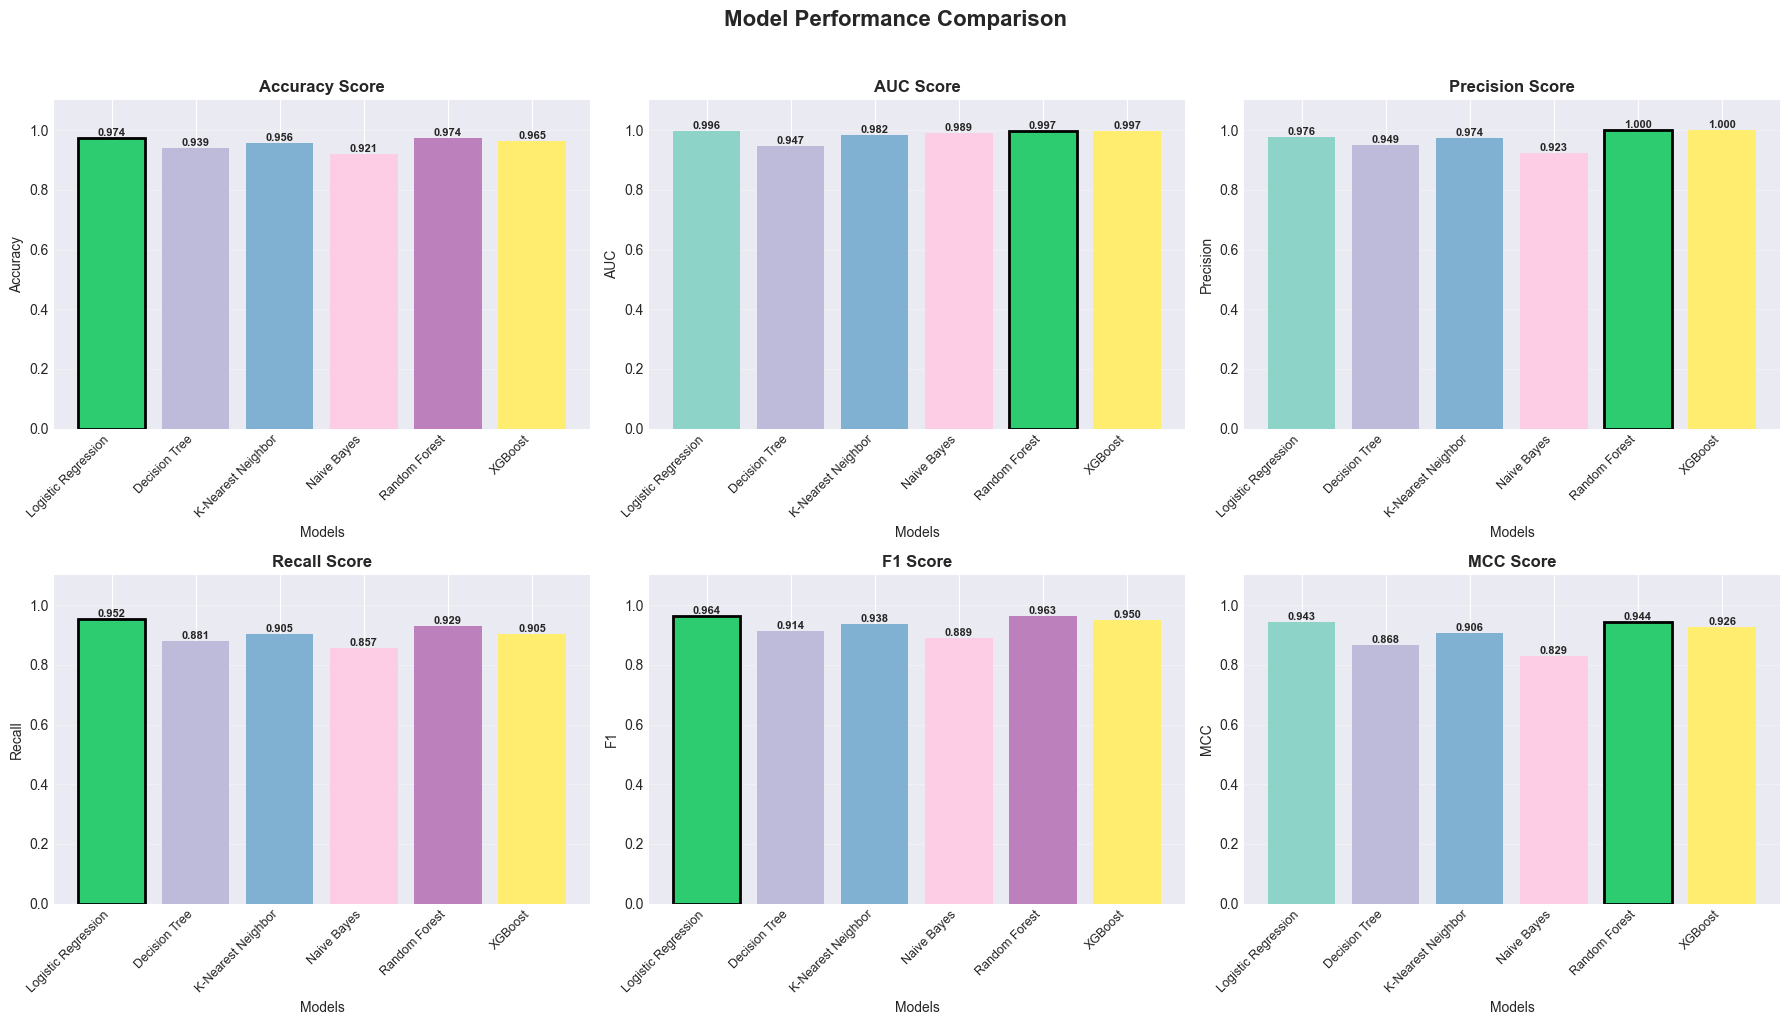

✅ Comparison plot saved!


In [16]:
# ==========================================
# MODEL PERFORMANCE VISUALIZATION
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)

metrics_to_plot = ['Accuracy', 'AUC', 'Precision', 'Recall', 'F1', 'MCC']
colors = plt.cm.Set3(np.linspace(0, 1, len(models)))

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]
    
    bars = ax.bar(range(len(results_df)), results_df[metric], color=colors)
    
    ax.set_title(f'{metric} Score', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric, fontsize=10)
    ax.set_xlabel('Models', fontsize=10)
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['ML Model Name'], rotation=45, ha='right', fontsize=9)
    ax.set_ylim([0, 1.1])
    ax.grid(axis='y', alpha=0.3)
    
    # Add values on bars
    for i, bar in enumerate(bars):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    # Highlight best
    best_idx = results_df[metric].idxmax()
    bars[best_idx].set_color('#2ecc71')
    bars[best_idx].set_edgecolor('black')
    bars[best_idx].set_linewidth(2)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Comparison plot saved!")

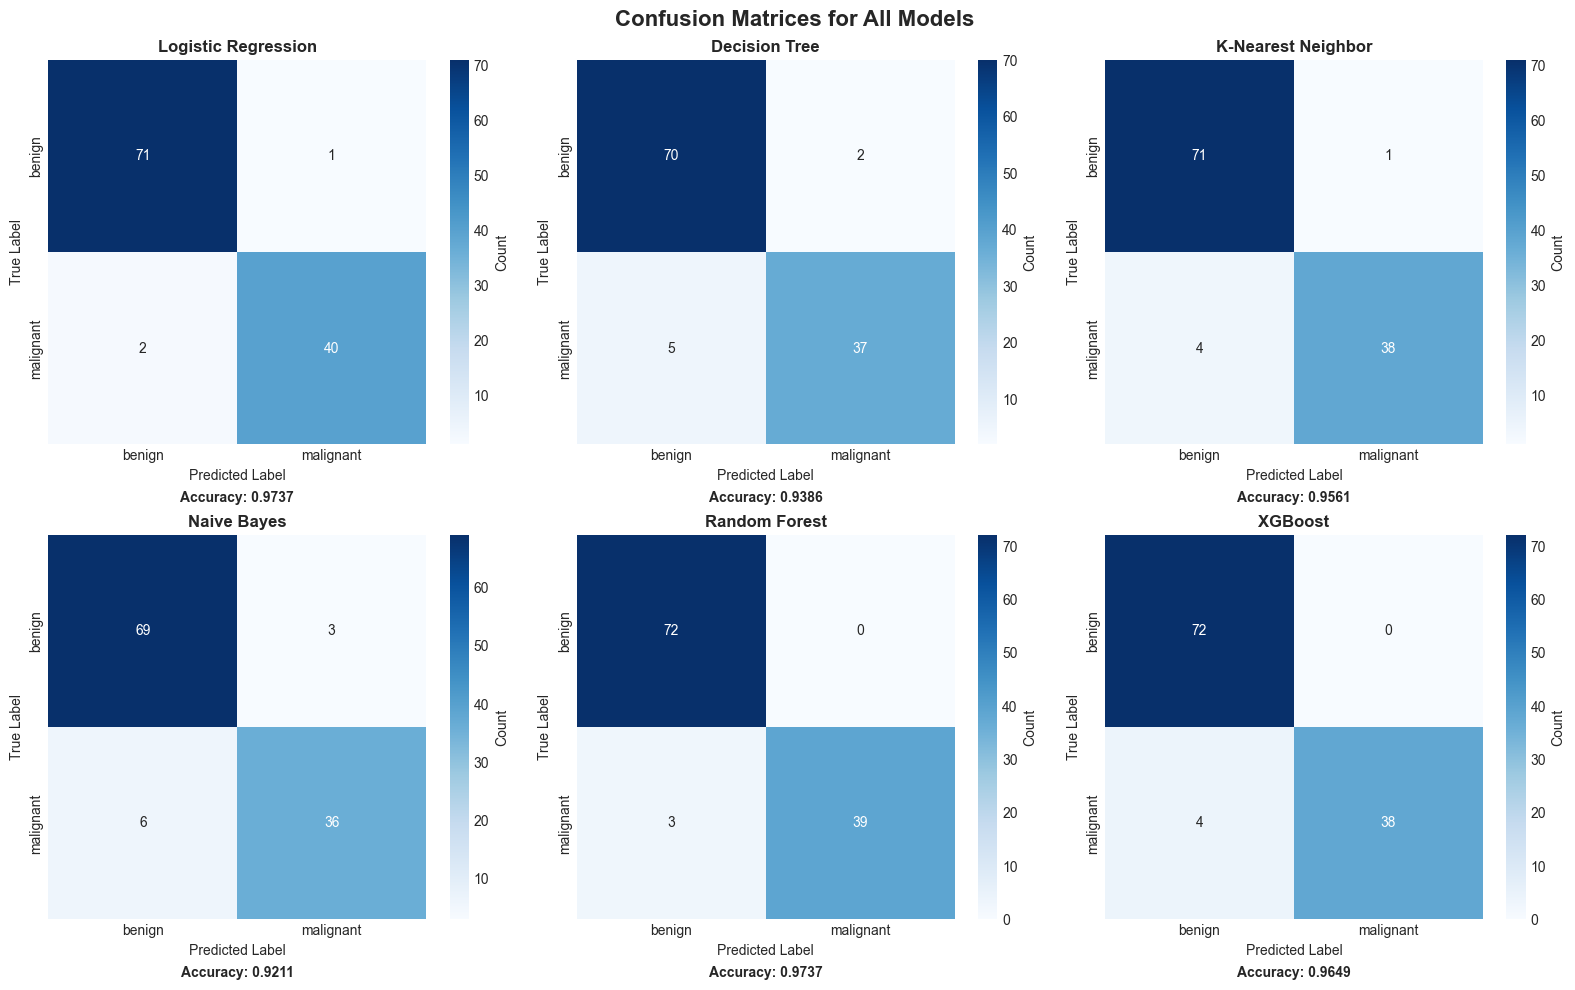

✅ Confusion matrices saved!


In [17]:
# ==========================================
# CONFUSION MATRICES VISUALIZATION
# ==========================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Confusion Matrices for All Models', fontsize=16, fontweight='bold')

for idx, result in enumerate(all_results):
    ax = axes[idx // 3, idx % 3]
    cm = result['Confusion Matrix']
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar_kws={'label': 'Count'},
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    
    ax.set_title(result['ML Model Name'], fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=10)
    ax.set_xlabel('Predicted Label', fontsize=10)
    
    accuracy = result['Accuracy']
    ax.text(0.5, -0.15, f'Accuracy: {accuracy:.4f}', 
            ha='center', transform=ax.transAxes, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrices saved!")

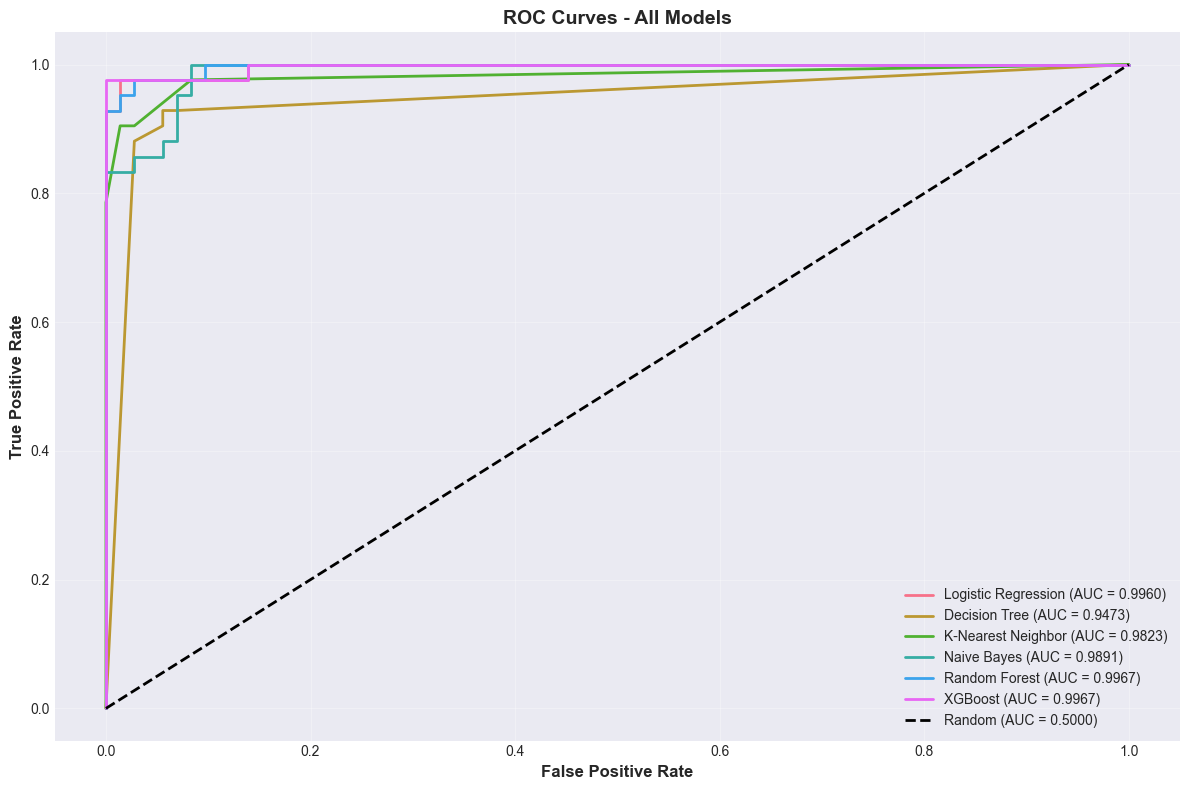

✅ ROC curves saved!


In [18]:
# ==========================================
# ROC CURVES
# ==========================================

fig, ax = plt.subplots(figsize=(12, 8))

for result in all_results:
    model_name = result['ML Model Name']
    model_filename = f"{model_name.lower().replace(' ', '_')}_model.pkl"
    model_path = os.path.join(MODEL_DIR, model_filename)
    
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    
    try:
        if hasattr(model, 'predict_proba'):
            y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
        elif hasattr(model, 'decision_function'):
            y_pred_proba = model.decision_function(X_test_scaled)
        else:
            continue
        
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = result['AUC']
        
        ax.plot(fpr, tpr, linewidth=2, label=f'{model_name} (AUC = {auc_score:.4f})')
    
    except Exception as e:
        print(f"⚠️ Could not plot ROC for {model_name}: {e}")

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves - All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/roc_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC curves saved!")


🌲 FEATURE IMPORTANCE ANALYSIS

📊 Top 10 Most Important Features:
             Feature  Importance
          worst area    0.150803
worst concave points    0.132394
        worst radius    0.094819
 mean concave points    0.086863
     worst perimeter    0.084278
      mean perimeter    0.081592
         mean radius    0.062960
      mean concavity    0.051505
           mean area    0.047969
     worst concavity    0.031415


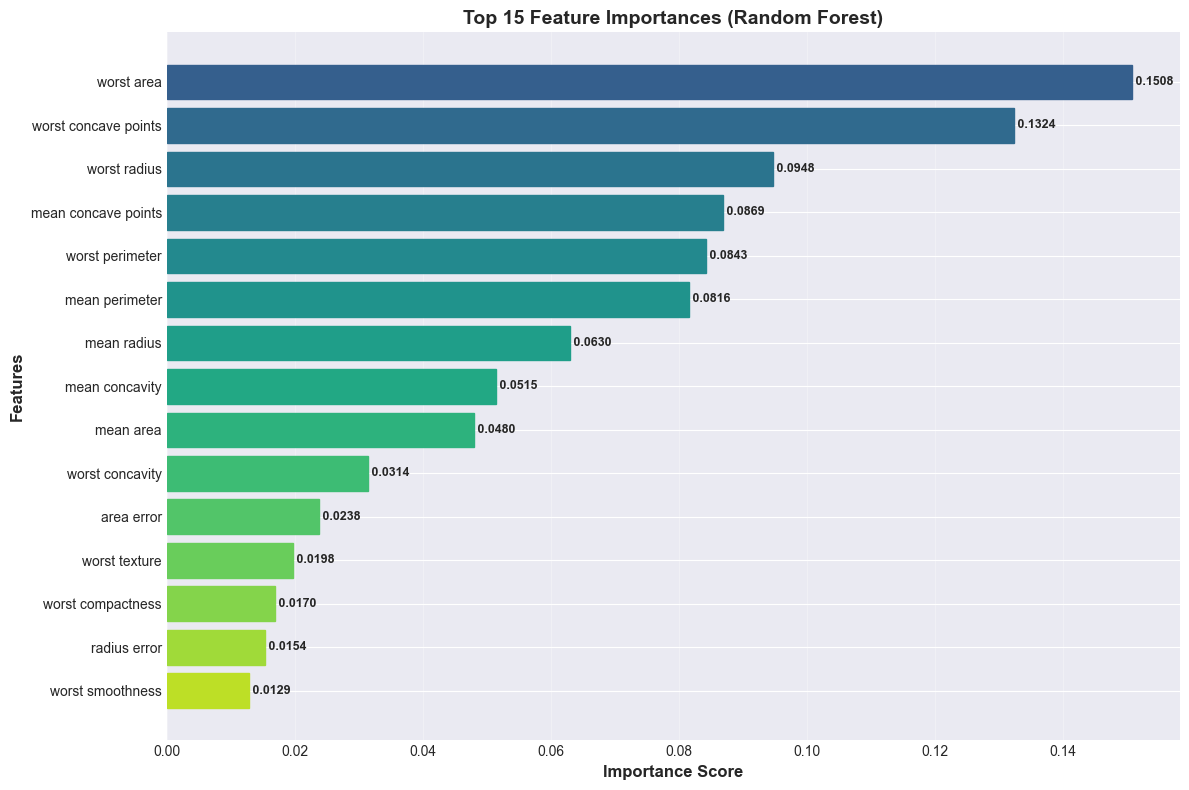

✅ Feature importance plot saved!


In [19]:
# ==========================================
# FEATURE IMPORTANCE (Random Forest)
# ==========================================

print("\n" + "="*80)
print("🌲 FEATURE IMPORTANCE ANALYSIS")
print("="*80)

rf_path = os.path.join(MODEL_DIR, 'random_forest_model.pkl')
with open(rf_path, 'rb') as f:
    rf_model = pickle.load(f)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n📊 Top 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(12, 8))
top_n = min(15, len(feature_importance))
top_features = feature_importance.head(top_n)

bars = plt.barh(range(top_n), top_features['Importance'])
plt.yticks(range(top_n), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Feature Importances (Random Forest)', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
for bar, color in zip(bars, colors):
    bar.set_color(color)

for i, (idx, row) in enumerate(top_features.iterrows()):
    plt.text(row['Importance'], i, f" {row['Importance']:.4f}", 
             va='center', fontsize=9, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plot saved!")

In [20]:
# ==========================================
# EXPORT COMPLETE RESULTS
# ==========================================

print("\n" + "="*80)
print("💾 EXPORTING RESULTS")
print("="*80)

# Training report
report = {
    'execution_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_path': DATASET_PATH,
    'total_samples': len(df),
    'training_samples': len(X_train),
    'test_samples': len(X_test),
    'num_features': X.shape[1],
    'models_trained': len(all_results),
    'best_model': results_df.loc[results_df['Accuracy'].idxmax(), 'ML Model Name'],
    'best_accuracy': float(results_df['Accuracy'].max()),
    'average_accuracy': float(results_df['Accuracy'].mean())
}

report_path = os.path.join(RESULTS_DIR, 'training_report.json')
with open(report_path, 'w') as f:
    json.dump(report, f, indent=4)
print(f"✅ Training report: {report_path}")

# Detailed results
detailed_results = []
for result in all_results:
    detailed_results.append({
        'model': result['ML Model Name'],
        'accuracy': float(result['Accuracy']),
        'auc': float(result['AUC']),
        'precision': float(result['Precision']),
        'recall': float(result['Recall']),
        'f1': float(result['F1']),
        'mcc': float(result['MCC']),
        'confusion_matrix': result['Confusion Matrix'].tolist()
    })

detailed_path = os.path.join(RESULTS_DIR, 'detailed_results.json')
with open(detailed_path, 'w') as f:
    json.dump(detailed_results, f, indent=4)
print(f"✅ Detailed results: {detailed_path}")

print("\n📊 All results exported successfully!")


💾 EXPORTING RESULTS
✅ Training report: results\training_report.json
✅ Detailed results: results\detailed_results.json

📊 All results exported successfully!


In [21]:
# ==========================================
# FINAL SUMMARY
# ==========================================

print("\n" + "="*80)
print("🎉 TRAINING COMPLETE!")
print("="*80)

print(f"\n✅ Successfully trained {len(all_results)} models")
print(f"✅ Generated {len(os.listdir(RESULTS_DIR))} result files")
print(f"✅ Saved {len(os.listdir(MODEL_DIR))} model files")

print(f"\n📁 Output Files:")
print(f"\n   Models ({MODEL_DIR}/):")
for file in sorted(os.listdir(MODEL_DIR)):
    print(f"      - {file}")

print(f"\n   Results ({RESULTS_DIR}/):")
for file in sorted(os.listdir(RESULTS_DIR)):
    print(f"      - {file}")

print(f"\n🏆 Best Model:")
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'ML Model Name']
best_accuracy = results_df['Accuracy'].max()
print(f"   Model: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")

print("\n" + "="*80)
print("💡 NEXT STEPS")
print("="*80)
print("1. Review model_results.csv for detailed comparison")
print("2. Check visualizations in results/ directory")
print("3. Use trained models in Streamlit app (app.py)")
print("4. Deploy app on Streamlit Community Cloud")

print(f"\n📅 Completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80 + "\n")

print("🎓 BITS Pilani - ML Assignment 2 Complete! ✅")


🎉 TRAINING COMPLETE!

✅ Successfully trained 6 models
✅ Generated 8 result files
✅ Saved 7 model files

📁 Output Files:

   Models (models/):
      - decision_tree_model.pkl
      - k-nearest_neighbor_model.pkl
      - logistic_regression_model.pkl
      - naive_bayes_model.pkl
      - random_forest_model.pkl
      - scaler.pkl
      - xgboost_model.pkl

   Results (results/):
      - class_distribution.png
      - confusion_matrices.png
      - detailed_results.json
      - feature_importance.png
      - model_comparison.png
      - model_results.csv
      - roc_curves.png
      - training_report.json

🏆 Best Model:
   Model: Logistic Regression
   Accuracy: 0.9737

💡 NEXT STEPS
1. Review model_results.csv for detailed comparison
2. Check visualizations in results/ directory
3. Use trained models in Streamlit app (app.py)
4. Deploy app on Streamlit Community Cloud

📅 Completed at: 2026-01-27 03:32:09

🎓 BITS Pilani - ML Assignment 2 Complete! ✅
